In [1]:
import keras
import tensorflow as tf

from keras import layers as tfkl
from keras import ops
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from scipy.fftpack import dct, idct
import os

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape)

(60000, 28, 28)


In [47]:
print(np.where(y_train == 4 , 1 , 0))

[0 0 1 ... 0 0 0]


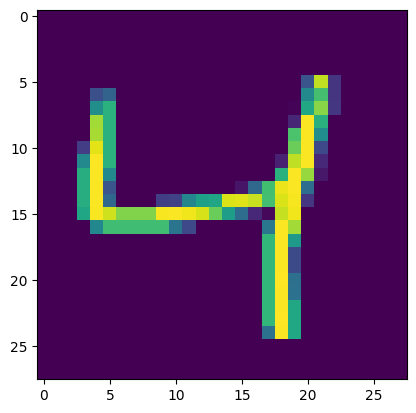

In [48]:
plt.imshow(x_train[2,:,:])

# Compressed Sensing using LASSO with DCT basis


In [52]:
def Lasso_DCT(sample_dimensions,N,x_star):
    results = []
    for el in sample_dimensions:
        M = el

        # Generate the measurement matrix and noise eta
        A = np.random.randn(M,N)
        eta = np.random.randn(M,1)* 0.1
        A_dct = A @ dct(np.eye(N) , norm = 'ortho')
        # Generate from a true image x_star the corresponding compressed signal y
        x_star = x_star.reshape(N,-1)

        # Generate the compressed signal y from the measurement matrix, the original matrix and noise
        y = A @x_star + eta

        # Use LASSO to find the set opf coefficient minimizing the problem+
        lasso = Lasso(alpha=0.1, max_iter=10000)
        lasso.fit(A_dct, y)
        theta_estimated = lasso.coef_
        x_reconstructed = idct(theta_estimated , norm = 'ortho')
        
        results.append(x_reconstructed)
    return results

In [68]:
samples,row_size,col_size = x_train.shape
N = row_size*col_size

# Given an image from the dataset, unrolled in one dimension, let's see the reconstruction at various sampling dimensions
image = x_train[2,:,:].reshape((-1))
sampling_dimensions = np.arange(100 , 800 , 10)
reconstructions = Lasso_DCT(sampling_dimensions , N , image)


In [69]:
errors = [np.sqrt(np.mean((r - image)**2))/N for r in reconstructions]

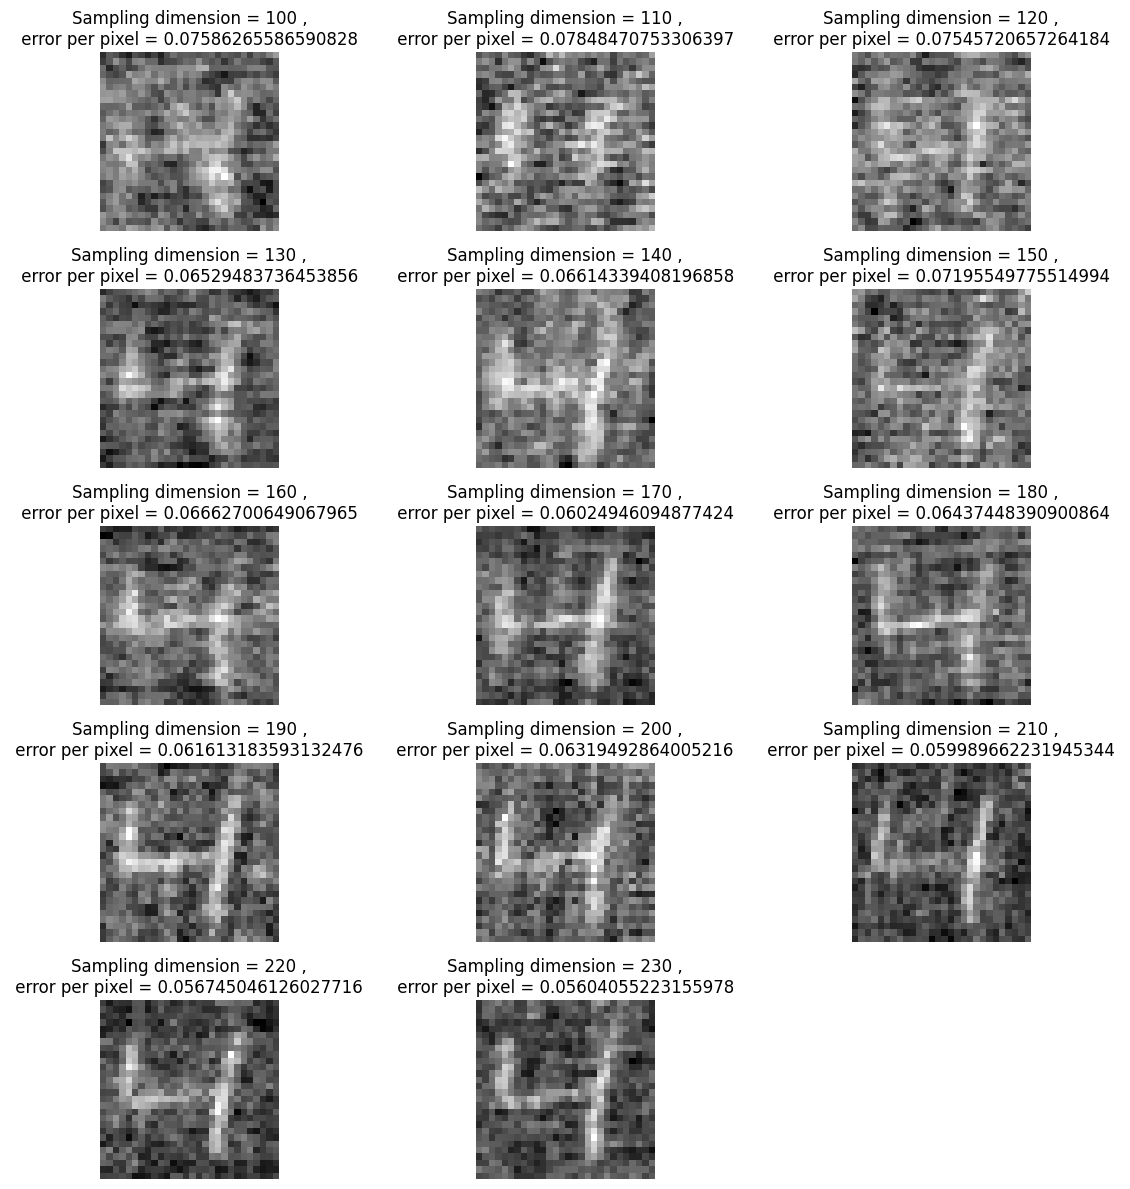

In [70]:
fig,axis = plt.subplots(5,3, figsize = (12,12))
axis = axis.reshape((-1))
for i in range(14):
    axis[i].imshow(reconstructions[i].reshape((28,28)) , cmap = 'gray')
    axis[i].set_title(f'Sampling dimension = {sampling_dimensions[i]} ,\n error per pixel = {errors[i]} ')
    axis[i].axis('off')

for j in range(14, 15):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

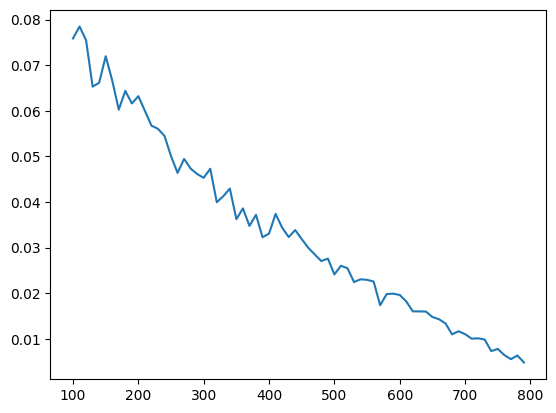

In [72]:
plt.plot(sampling_dimensions , errors )